In [3]:
from datasets import load_dataset
import numpy as np

data_path = "ionosphere.data"

ds = load_dataset(
    "csv",
    data_files={"train": data_path},
    delimiter=",",
    header=None,
    skip_blank_lines=True,
)["train"]

n_cols = len(ds.column_names)
assert n_cols == 35, f"Expected 35 columns (34 features + label), got {n_cols}"

new_names = [f"f{i}" for i in range(34)] + ["label"]
ds = ds.rename_columns({old: new for old, new in zip(ds.column_names, new_names)})

ds = ds.map(lambda ex: {"label_int": 1 if ex["label"] == "g" else 0})

print(ds.to_pandas().head())

X = ds.remove_columns(["label", "label_int"]).to_pandas().to_numpy(dtype=float)
y = np.array(ds["label_int"])
print(X.shape, y.shape)


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/351 [00:00<?, ? examples/s]

   f0  f1       f2       f3       f4       f5       f6       f7       f8  \
0   1   0  0.99539 -0.05889  0.85243  0.02306  0.83398 -0.37708  1.00000   
1   1   0  1.00000 -0.18829  0.93035 -0.36156 -0.10868 -0.93597  1.00000   
2   1   0  1.00000 -0.03365  1.00000  0.00485  1.00000 -0.12062  0.88965   
3   1   0  1.00000 -0.45161  1.00000  1.00000  0.71216 -1.00000  0.00000   
4   1   0  1.00000 -0.02401  0.94140  0.06531  0.92106 -0.23255  0.77152   

        f9  ...      f26      f27      f28      f29      f30      f31  \
0  0.03760  ...  0.41078 -0.46168  0.21266 -0.34090  0.42267 -0.54487   
1 -0.04549  ... -0.20468 -0.18401 -0.19040 -0.11593 -0.16626 -0.06288   
2  0.01198  ...  0.58984 -0.22145  0.43100 -0.17365  0.60436 -0.24180   
3  0.00000  ...  0.51613  1.00000  1.00000 -0.20099  0.25682  1.00000   
4 -0.16399  ...  0.13290 -0.53206  0.02431 -0.62197 -0.05707 -0.59573   

       f32      f33  label  label_int  
0  0.18641 -0.45300      g          1  
1 -0.13738 -0.02447     

In [4]:
from sklearn.model_selection import KFold

kfold = KFold(random_state=42, shuffle=True)

In [5]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

def plot_decision_regions(X, y, classifier, test_idx=None, resolution=0.02):
    markers = ("o", "s", "^", "v", "<")
    colors = ("blue", "red", "lightgreen", "gray", "cyan")
    cmap = ListedColormap(colors[:len(np.unique(y))])

    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    x2_min, x2_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx1, xx2 = np.meshgrid(np.arange(x1_min, x1_max, resolution),
                           np.arange(x2_min, x2_max, resolution))

    lab = classifier.predict(np.array([xx1.ravel(), xx2.ravel()]).T)
    lab = lab.reshape(xx1.shape)

    plt.contourf(xx1, xx2, lab, alpha=0.3, cmap=cmap)
    plt.xlim(xx1.min(), xx1.max())
    plt.ylim(xx2.min(), xx2.max())

    for idx, cl in enumerate(np.unique(y)):
        plt.scatter(x=X[y == cl, 0],
                    y=X[y == cl, 1],
                    alpha=0.8,
                    c=colors[idx],
                    marker=markers[idx],
                    label=f"Class {cl}",
                    edgecolor="black")

In [6]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier

def train_models_cv(X, y, kfold):
    scoring = {
        "accuracy": "accuracy",
        "f1": "f1",
        "roc_auc": "roc_auc",
    }

    models = {
        "DecisionTree": DecisionTreeClassifier(random_state=42),
        "RandomForest": RandomForestClassifier(random_state=42),
        "LogisticRegression": LogisticRegression(random_state=42),
        "SVM_RBF": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", SVC(random_state=42))
        ]),
        "MLP": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", MLPClassifier(random_state=42, max_iter=1000))
        ]),
    }

    rows = []
    for name, model in models.items():
        cv_out = cross_validate(
            model, X, y,
            cv=kfold,
            scoring=scoring,
            n_jobs=-1,
            return_train_score=True
        )
        rows.append({
            "model": name,
            "acc_mean": np.mean(cv_out["test_accuracy"]),
            "acc_std":  np.std(cv_out["test_accuracy"]),
            "f1_mean":  np.mean(cv_out["test_f1"]),
            "f1_std":   np.std(cv_out["test_f1"]),
            "auc_mean": np.mean(cv_out["test_roc_auc"]),
            "auc_std":  np.std(cv_out["test_roc_auc"]),
            "train_acc_mean": np.mean(cv_out["train_accuracy"]),
            "train_f1_mean":  np.mean(cv_out["train_f1"]),
            "train_auc_mean": np.mean(cv_out["train_roc_auc"]),
        })

    results = pd.DataFrame(rows).sort_values(by="auc_mean", ascending=False)
    return results

results_ionosphere = train_models_cv(X, y, kfold)
display(results_ionosphere)

,model,acc_mean,acc_std,f1_mean,f1_std,auc_mean,auc_std,train_acc_mean,train_f1_mean,train_auc_mean
3,SVM_RBF,0.943018,0.023907,0.957413,0.015341,0.981513,0.018725,0.969370,0.976374,0.990072
1,RandomForest,0.931590,0.026258,0.947892,0.017594,0.979851,0.017682,1.000000,1.000000,1.000000
4,MLP,0.911710,0.037607,0.935041,0.027816,0.950167,0.035046,0.997150,0.997796,0.999967
2,LogisticRegression,0.877545,0.024596,0.910359,0.016340,0.903781,0.053712,0.913111,0.934709,0.971903
0,DecisionTree,0.894608,0.014392,0.919212,0.008935,0.881656,0.015834,1.000000,1.000000,1.000000


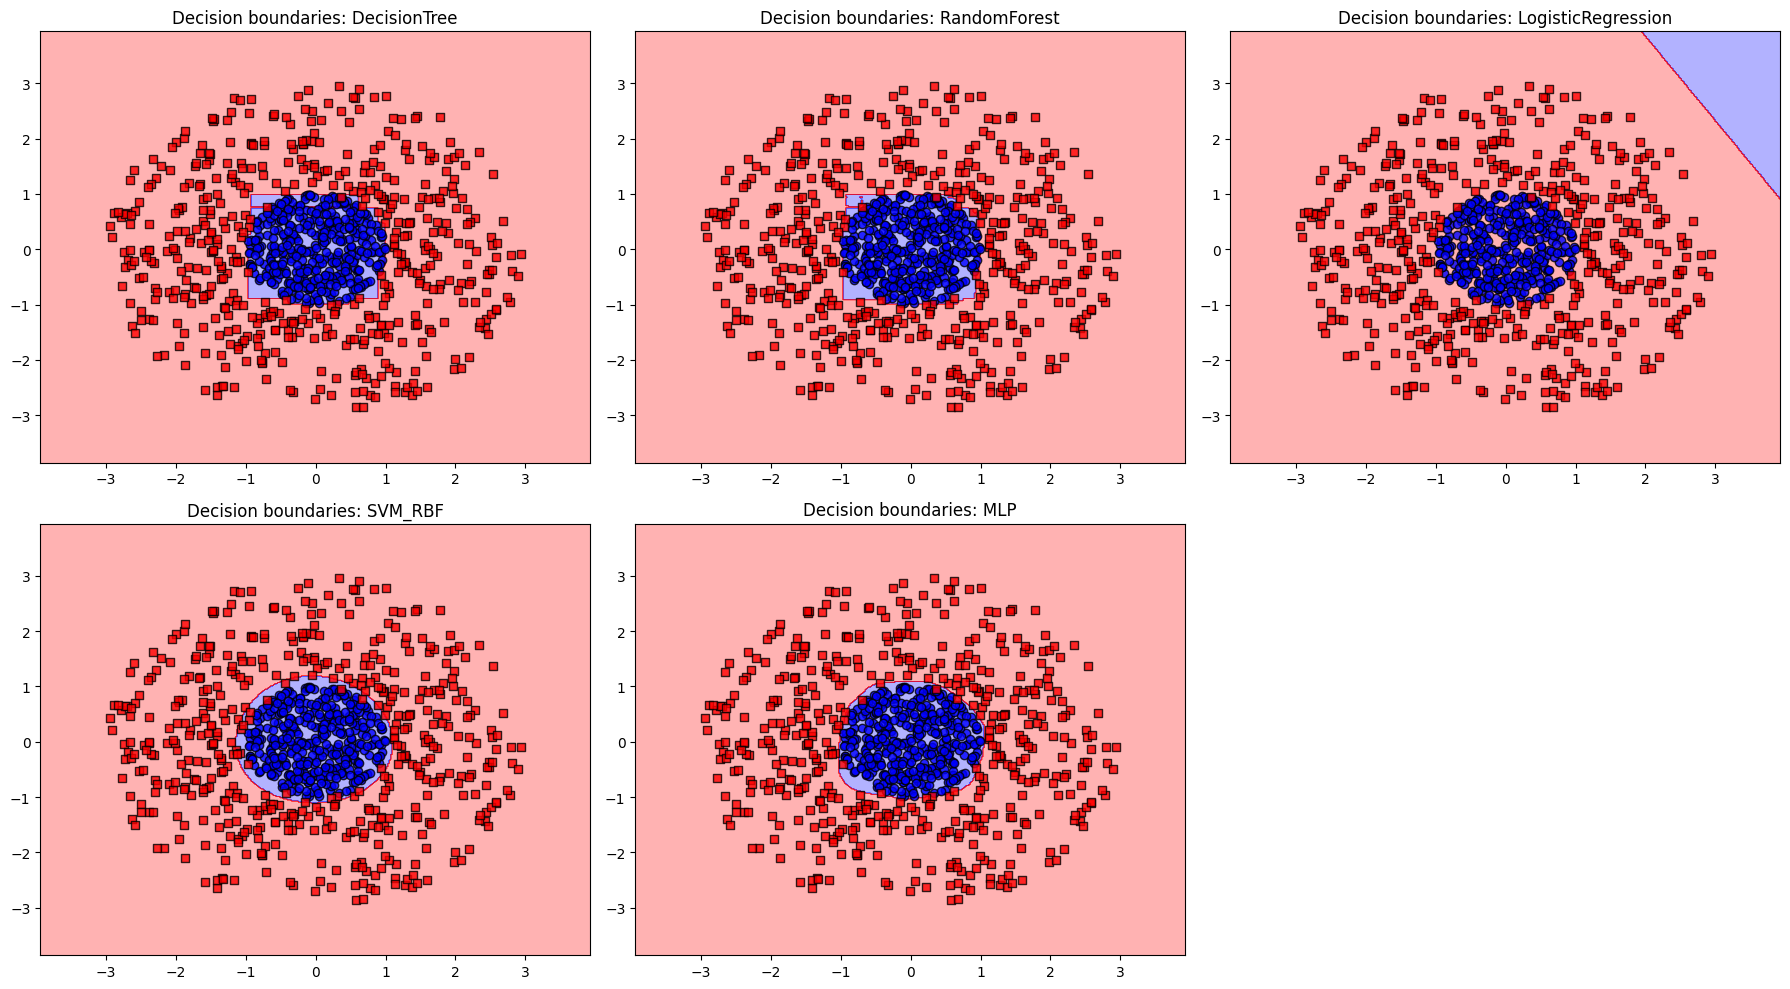

In [8]:

dataset_space = load_dataset("csv", data_files="space.csv")["train"]

X_space = np.column_stack([dataset_space["x"], dataset_space["y"]]).astype(float)
y_space = np.array(dataset_space["label"])

models_2d = {
    "DecisionTree": DecisionTreeClassifier(random_state=42),
    "RandomForest": RandomForestClassifier(random_state=42),
    "LogisticRegression": LogisticRegression(random_state=42),
    "SVM_RBF": Pipeline([("scaler", StandardScaler()), ("clf", SVC(random_state=42))]),
    "MLP": Pipeline([("scaler", StandardScaler()), ("clf", MLPClassifier(random_state=42, max_iter=1000))])
}

plt.figure(figsize=(18, 10))

for i, (name, model) in enumerate(models_2d.items(), 1):
    model.fit(X_space, y_space)

    plt.subplot(2, 3, i)
    plot_decision_regions(X_space, y_space, model)
    plt.title(f"Decision boundaries: {name}")

plt.tight_layout()
plt.show()